In [6]:
import duckdb
import pandas as pd
import numpy as np

csv_path   = "/Users/aaditya/VS Code/1000 genome project/Data/chrX_full.csv"
panel_path = "/Users/aaditya/VS Code/1000 genome project/integrated_call_samples_v3.20130502.ALL.panel"
out_dir    = "/Users/aaditya/VS Code/1000 genome project/Code/"

con = duckdb.connect()
print("DuckDB ready")

DuckDB ready


In [7]:
# --- Get column names from header row ---
cols_df = con.execute(f"""
    DESCRIBE SELECT * FROM read_csv_auto('{csv_path}', header=true) LIMIT 1
""").df()

all_cols = cols_df['column_name'].tolist()
fixed    = ['#CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT']
sample_cols = [c for c in all_cols if c not in fixed]

print(f"Total columns : {len(all_cols)}")
print(f"Sample columns: {len(sample_cols)}")
print("First 5 samples:", sample_cols[:5])

Total columns : 2513
Sample columns: 2504
First 5 samples: ['HG00096', 'HG00097', 'HG00099', 'HG00100', 'HG00101']


In [8]:
# --- Load population panel (same file as Y analysis) ---
panel = pd.read_csv(panel_path, sep='\t')
panel = panel.rename(columns={'super_pop': 'POP'})
panel = panel[['sample','POP','gender']]

# Keep only samples present in the VCF
meta = panel[panel['sample'].isin(sample_cols)].copy()
print(meta['POP'].value_counts())
print(meta['gender'].value_counts())

POP
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64
gender
female    1271
male      1233
Name: count, dtype: int64


In [9]:
# --- Helper: parse genotype string to allele dosage (0, 0.5, 1, or NaN) ---
# X chr: females are diploid (0|0, 0|1, 1|1), males are hemizygous (0, 1)
GT_MAP = {
    '0': 0.0,  '1': 1.0,
    '0|0': 0.0, '0/0': 0.0,
    '0|1': 0.5, '1|0': 0.5,
    '0/1': 0.5, '1/0': 0.5,
    '1|1': 1.0, '1/1': 1.0,
    '.': np.nan, './.': np.nan, '.|.': np.nan,
}

def parse_gt_series(s: pd.Series) -> pd.Series:
    return s.map(GT_MAP)

In [10]:
# --- Stream through the 27 GB CSV in chunks and compute per-variant stats ---
# Mirrors y_analysis: FILTER=PASS, QUAL>30, biallelic only

CHUNK_SIZE = 2000   # variants per chunk — tune down if memory is tight

variant_rows   = []
sample_alt     = pd.Series(0.0, index=sample_cols)
sample_missing = pd.Series(0,   index=sample_cols)
sample_called  = pd.Series(0,   index=sample_cols)
total_variants = 0

print("Streaming CSV... (this will take a while for a 27 GB file)")

for chunk in pd.read_csv(
        csv_path,
        sep=',',
        chunksize=CHUNK_SIZE,
        low_memory=False,
        dtype=str):

    chunk.columns = [c.strip().lstrip('\ufeff') for c in chunk.columns]

    qual = pd.to_numeric(chunk.get('QUAL', pd.Series(dtype=float)), errors='coerce')

    filter_col = next((c for c in chunk.columns if c.upper() == 'FILTER'), None)
    if filter_col:
        mask = (chunk[filter_col].str.upper() == 'PASS') & (qual > 30)
    else:
        mask = qual > 30

    # biallelic only
    mask &= ~chunk['ALT'].astype(str).str.contains(',', na=False)

    chunk = chunk[mask].copy()
    if chunk.empty:
        continue

    present = [c for c in sample_cols if c in chunk.columns]
    G = chunk[present].apply(parse_gt_series)

    call_rate = 1 - G.isna().mean(axis=1)
    af        = G.mean(axis=1, skipna=True)

    chrom_col = '#CHROM' if '#CHROM' in chunk.columns else 'CHROM'
    summary_chunk = pd.DataFrame({
        '#CHROM'   : chunk[chrom_col].values,
        'POS'      : chunk['POS'].values,
        'ID'       : chunk['ID'].values,
        'REF'      : chunk['REF'].values,
        'ALT'      : chunk['ALT'].values,
        'QUAL'     : qual[mask].values,
        'call_rate': call_rate.values,
        'AF'       : af.values,
    })
    variant_rows.append(summary_chunk)

    sample_alt[present]     += G.sum(skipna=True).values
    sample_missing[present] += G.isna().sum().values
    sample_called[present]  += (~G.isna()).sum().values

    total_variants += len(chunk)
    if total_variants % 100_000 == 0:
        print(f"  {total_variants:,} variants processed", flush=True)

variant_summary = pd.concat(variant_rows, ignore_index=True)
print(f"\nDone. {total_variants:,} variants passed initial QC.")
print(variant_summary.head())

Streaming CSV... (this will take a while for a 27 GB file)

Done. 3,437,097 variants passed initial QC.
  #CHROM    POS ID REF ALT  QUAL  call_rate        AF
0      X  60026  .   T   C   100        1.0  0.004992
1      X  60032  .   T   C   100        1.0  0.005591
2      X  60052  .   T   A   100        1.0  0.315895
3      X  60057  .   G   C   100        1.0  0.000200
4      X  60060  .   G   C   100        1.0  0.048922


In [11]:
# --- Apply QC thresholds (same as Y analysis) ---
keep = (variant_summary['call_rate'] >= 0.95) & (variant_summary['QUAL'] >= 30)
vs_clean = variant_summary[keep].reset_index(drop=True)
print(f"After QC: {len(vs_clean):,} variants retained")

vs_clean.to_csv(out_dir + "chrX_variant_summary_qc.csv", index=False)
print("Saved: chrX_variant_summary_qc.csv")

After QC: 3,437,097 variants retained
Saved: chrX_variant_summary_qc.csv


In [12]:
# --- Per-sample QC summary (same structure as Y analysis) ---
total_called = sample_called + sample_missing
missing_rate = sample_missing / total_called.replace(0, np.nan)

sample_summary = pd.DataFrame({
    'sample'      : sample_cols,
    'missing_rate': missing_rate[sample_cols].values,
    'alt_burden'  : sample_alt[sample_cols].values,
})

sample_summary.to_csv(out_dir + "chrX_sample_summary_qc.csv", index=False)
print("Saved: chrX_sample_summary_qc.csv")
print(sample_summary.describe())

Saved: chrX_sample_summary_qc.csv
       missing_rate     alt_burden
count        2504.0    2504.000000
mean            0.0  105576.102037
std             0.0   15062.075818
min             0.0   88383.500000
25%             0.0   95652.625000
50%             0.0   97938.750000
75%             0.0  123718.500000
max             0.0  137878.000000


In [13]:
# --- Population-level allele frequency (same logic as Y analysis) ---
# Second pass: only load QC-passed variants

clean_pos  = set(zip(vs_clean['#CHROM'].astype(str), vs_clean['POS'].astype(str)))
pop_map    = meta.set_index('sample')['POP'].to_dict()
populations = sorted(meta['POP'].unique())
idx_map    = {(str(r['#CHROM']), str(r['POS'])): i for i, r in vs_clean.iterrows()}

pop_alt    = {p: np.zeros(len(vs_clean)) for p in populations}
pop_called = {p: np.zeros(len(vs_clean)) for p in populations}

print("Second pass: computing population-level AF...")

for chunk in pd.read_csv(
        csv_path,
        sep=',',
        chunksize=CHUNK_SIZE,
        low_memory=False,
        dtype=str):

    chunk.columns = [c.strip().lstrip('\ufeff') for c in chunk.columns]
    chrom_col = '#CHROM' if '#CHROM' in chunk.columns else 'CHROM'

    keys = list(zip(chunk[chrom_col].astype(str), chunk['POS'].astype(str)))
    in_clean_mask = [k in clean_pos for k in keys]
    chunk = chunk[[c for c in [chrom_col, 'POS'] + sample_cols if c in chunk.columns]]
    chunk = chunk[in_clean_mask].copy()
    if chunk.empty:
        continue

    present = [c for c in sample_cols if c in chunk.columns]
    G = chunk[present].apply(parse_gt_series)

    for row_i, (chrom, pos) in enumerate(zip(chunk[chrom_col].astype(str), chunk['POS'].astype(str))):
        vi = idx_map.get((chrom, pos))
        if vi is None:
            continue
        g_row = G.iloc[row_i]
        for col in present:
            pop = pop_map.get(col)
            if pop is None:
                continue
            v = g_row[col]
            if not np.isnan(v):
                pop_alt[pop][vi]    += v
                pop_called[pop][vi] += 1

af_by_pop = pd.DataFrame(
    {p: np.where(pop_called[p] > 0, pop_alt[p] / pop_called[p], np.nan) for p in populations}
)
af_by_pop.to_csv(out_dir + "chrX_AF_by_population.csv", index=False)
print("Saved: chrX_AF_by_population.csv")
print(af_by_pop.head())

Second pass: computing population-level AF...


/var/folders/zb/kxynxq253nzdw55vwwpwbqpr0000gn/T/ipykernel_39278/619408787.py:49: RuntimeWarning: invalid value encountered in divide
  {p: np.where(pop_called[p] > 0, pop_alt[p] / pop_called[p], np.nan) for p in populations}


Saved: chrX_AF_by_population.csv
        AFR       AMR       EAS       EUR       SAS
0  0.003782  0.004323  0.000992  0.009940  0.006135
1  0.003782  0.004323  0.000992  0.012922  0.006135
2  0.366868  0.311239  0.215278  0.465209  0.200409
3  0.000756  0.000000  0.000000  0.000000  0.000000
4  0.177761  0.012968  0.000000  0.000994  0.000000


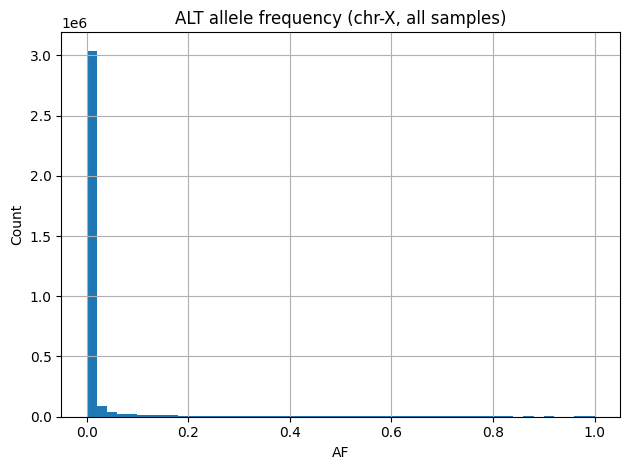

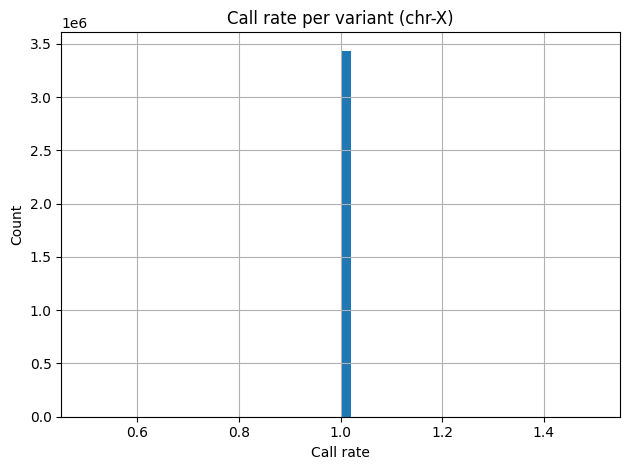

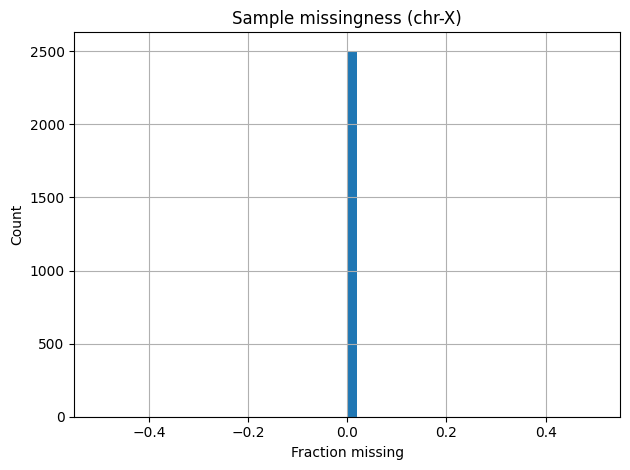

In [14]:
# --- Visualisations (mirrors deeper_analysis.ipynb) ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. AF histogram
vs_clean['AF'].hist(bins=50)
plt.title("ALT allele frequency (chr-X, all samples)")
plt.xlabel("AF"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

# 2. Call rate histogram
vs_clean['call_rate'].hist(bins=50)
plt.title("Call rate per variant (chr-X)")
plt.xlabel("Call rate"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

# 3. Sample missingness
sample_summary['missing_rate'].hist(bins=50)
plt.title("Sample missingness (chr-X)")
plt.xlabel("Fraction missing"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

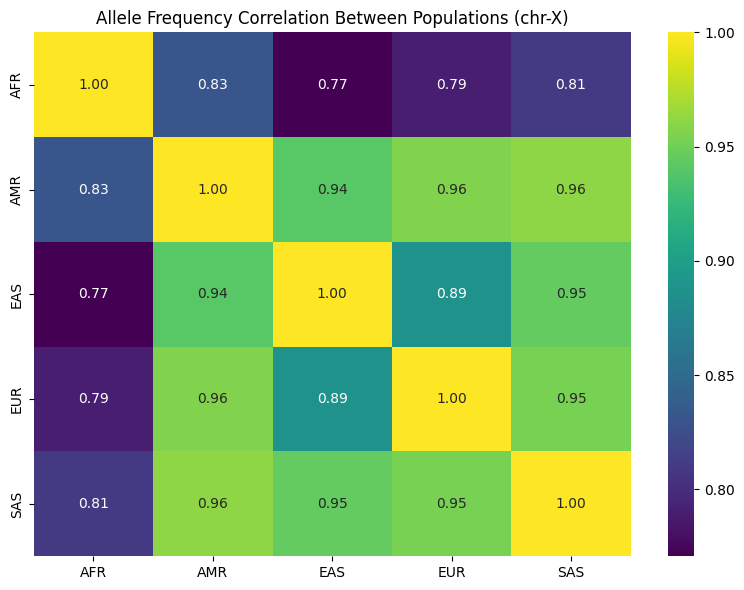

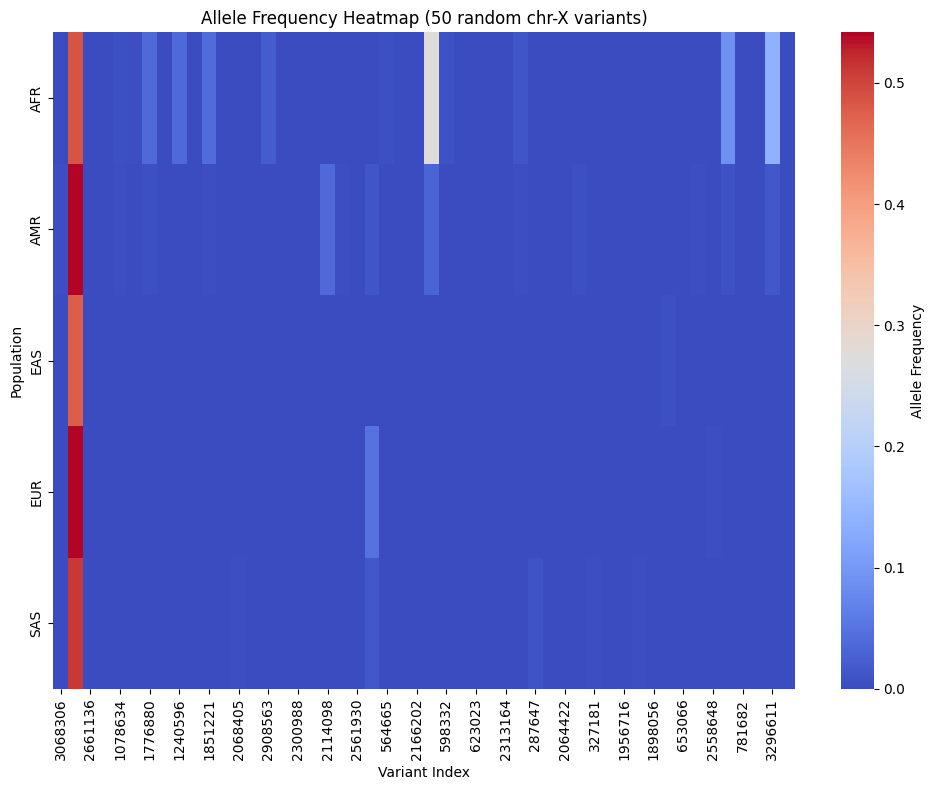

In [15]:
# 4. Population correlation heatmap
corr = af_by_pop[populations].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Allele Frequency Correlation Between Populations (chr-X)")
plt.tight_layout(); plt.show()

# 5. Variant-population heatmap (50 random variants)
subset = af_by_pop[populations].sample(n=min(50, len(af_by_pop)), random_state=42)
plt.figure(figsize=(10, 8))
sns.heatmap(subset.T, cmap="coolwarm", cbar_kws={'label': 'Allele Frequency'})
plt.xlabel("Variant Index"); plt.ylabel("Population")
plt.title("Allele Frequency Heatmap (50 random chr-X variants)")
plt.tight_layout(); plt.show()

In [16]:
# 6. Population-differentiated variants (max-min AF > 0.3, same threshold as Y)
diff = af_by_pop[populations].max(axis=1) - af_by_pop[populations].min(axis=1)
diff_variants = vs_clean[diff > 0.3].copy()
diff_variants['max_min_AF_diff'] = diff[diff > 0.3].values

print(f"Population-differentiated variants (delta AF > 0.3): {len(diff_variants):,}")
diff_variants.to_csv(out_dir + "chrX_differentiated_variants.csv", index=False)
print("Saved: chrX_differentiated_variants.csv")
print(diff_variants.head())

Population-differentiated variants (delta AF > 0.3): 132,173
Saved: chrX_differentiated_variants.csv
   #CHROM    POS ID REF ALT  QUAL  call_rate        AF  max_min_AF_diff
11      X  60112  .   G   C   100        1.0  0.098243         0.343419
18      X  60184  .   A   G   100        1.0  0.083267         0.301815
19      X  60185  .   T   C   100        1.0  0.435503         0.429064
20      X  60186  .   T   C   100        1.0  0.083267         0.301815
23      X  60215  .   A   C   100        1.0  0.492812         0.454048
